# California Housing House Grouping System

This notebook is the inspectable record of assignment Steps 1 through 5. It uses the reusable stages in `app.py` rather than one opaque `main()` call. Model inputs are only `Latitude`, `Longitude`, and `MedInc`.

In [1]:
from pathlib import Path
import sys
from IPython.display import Image, display

ROOT = Path.cwd().resolve()
if ROOT.name == "src":
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT / "src"))

import app

def display_repo_figure(absolute_path, relative_path):
    display(Image(data=Path(absolute_path).read_bytes(), format="png"))
    print(relative_path)

app.ensure_output_directories()
print("Features:", app.FEATURES)
print("n_clusters:", app.N_CLUSTERS, "random_state:", app.RANDOM_STATE)
print("models/kmeans_pipeline.joblib")
print("models/cluster_classifier.joblib")
print("reports/figures/kmeans_clusters.png")
print("reports/figures/cluster_income_analysis.png")
print("reports/figures/classifier_confusion_matrix.png")

Features: ['Latitude', 'Longitude', 'MedInc']
n_clusters: 6 random_state: 42
models/kmeans_pipeline.joblib
models/cluster_classifier.joblib
reports/figures/kmeans_clusters.png
reports/figures/cluster_income_analysis.png
reports/figures/classifier_confusion_matrix.png


## Step 1: Load and understand the dataset

The California Housing file has one row per 1990 census block group. Clustering uses only the three required columns. The 80/20 split is reproducible with `random_state=42` and is not used to compute training statistics on the test set.

In [2]:
raw = app.validate_data(app.load_raw_housing())
print("All columns:", list(raw.columns))
print(raw[app.FEATURES].describe().round(3))
X_train, X_test, train_idx, test_idx = app.split_features(raw)
assert len(X_train) == 16512
assert len(X_test) == 4128
print("Modeling columns only:", list(X_train.columns))

Dataset shape: (20640, 9)
Required dtypes:
 Latitude     float64
Longitude    float64
MedInc       float64
dtype: object
Missing values:
 Latitude     0
Longitude    0
MedInc       0
dtype: int64
Duplicate rows: 0
All columns: ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude', 'MedHouseVal']
        Latitude  Longitude     MedInc
count  20640.000  20640.000  20640.000
mean      35.632   -119.570      3.871
std        2.136      2.004      1.900
min       32.540   -124.350      0.500
25%       33.930   -121.800      2.563
50%       34.260   -118.490      3.535
75%       37.710   -118.010      4.743
max       41.950   -114.310     15.000
Train rows: 16512
Test rows: 4128
Modeling columns only: ['Latitude', 'Longitude', 'MedInc']


## Step 2: Fit six-cluster K-Means

K-Means is fitted only on the training features after median imputation and standard scaling. The six labels are stored in `cluster`. These labels are distance-based partitions in standardized `Latitude`, `Longitude`, and `MedInc` space. They are not official California regions.

In [3]:
kmeans, train_labels, test_labels = app.fit_kmeans(X_train, X_test)
labeled = app.build_labeled_dataset(raw, train_idx, test_idx, train_labels, test_labels)
cluster_ids = sorted(labeled["cluster"].dropna().unique().tolist())
print("Cluster IDs:", cluster_ids)
assert cluster_ids == [0, 1, 2, 3, 4, 5]
assert len(labeled) == 20640
assert labeled[["cluster", "split"]].notna().all().all()
cluster_plot = app.plot_kmeans_clusters(X_train, X_test, train_labels, test_labels)
income_plot = app.plot_income_by_cluster(labeled)
print("Saved: reports/figures/kmeans_clusters.png")
print("Saved: reports/figures/cluster_income_analysis.png")

K-Means clusters: [0, 1, 2, 3, 4, 5] counts: {0: 1321, 1: 3380, 2: 453, 3: 3931, 4: 2239, 5: 5188}


Processed rows: 20640
Split counts: {'train': 16512, 'test': 4128}
Cluster IDs: [0, 1, 2, 3, 4, 5]


MedInc by cluster:
           count       mean       std     min       25%      50%        75%  \
cluster                                                                      
0        1658.0   2.621249  0.883400  0.4999  1.939375   2.5554   3.207275   
1        4209.0   5.302799  0.989530  3.9485  4.500000   5.0912   5.952200   
2         565.0  10.456234  2.043603  7.5696  8.759100  10.1248  11.218500   
3        4893.0   2.828793  0.807018  0.4999  2.234000   2.8828   3.500000   
4        2753.0   5.513036  1.122860  3.9792  4.637100   5.2155   6.116800   
5        6562.0   2.788585  0.773223  0.4999  2.200000   2.8591   3.424675   

             max  
cluster           
0         4.9464  
1         8.4284  
2        15.0001  
3         4.5590  
4         9.5551  
5         4.1458  
Saved: reports/figures/kmeans_clusters.png
Saved: reports/figures/cluster_income_analysis.png


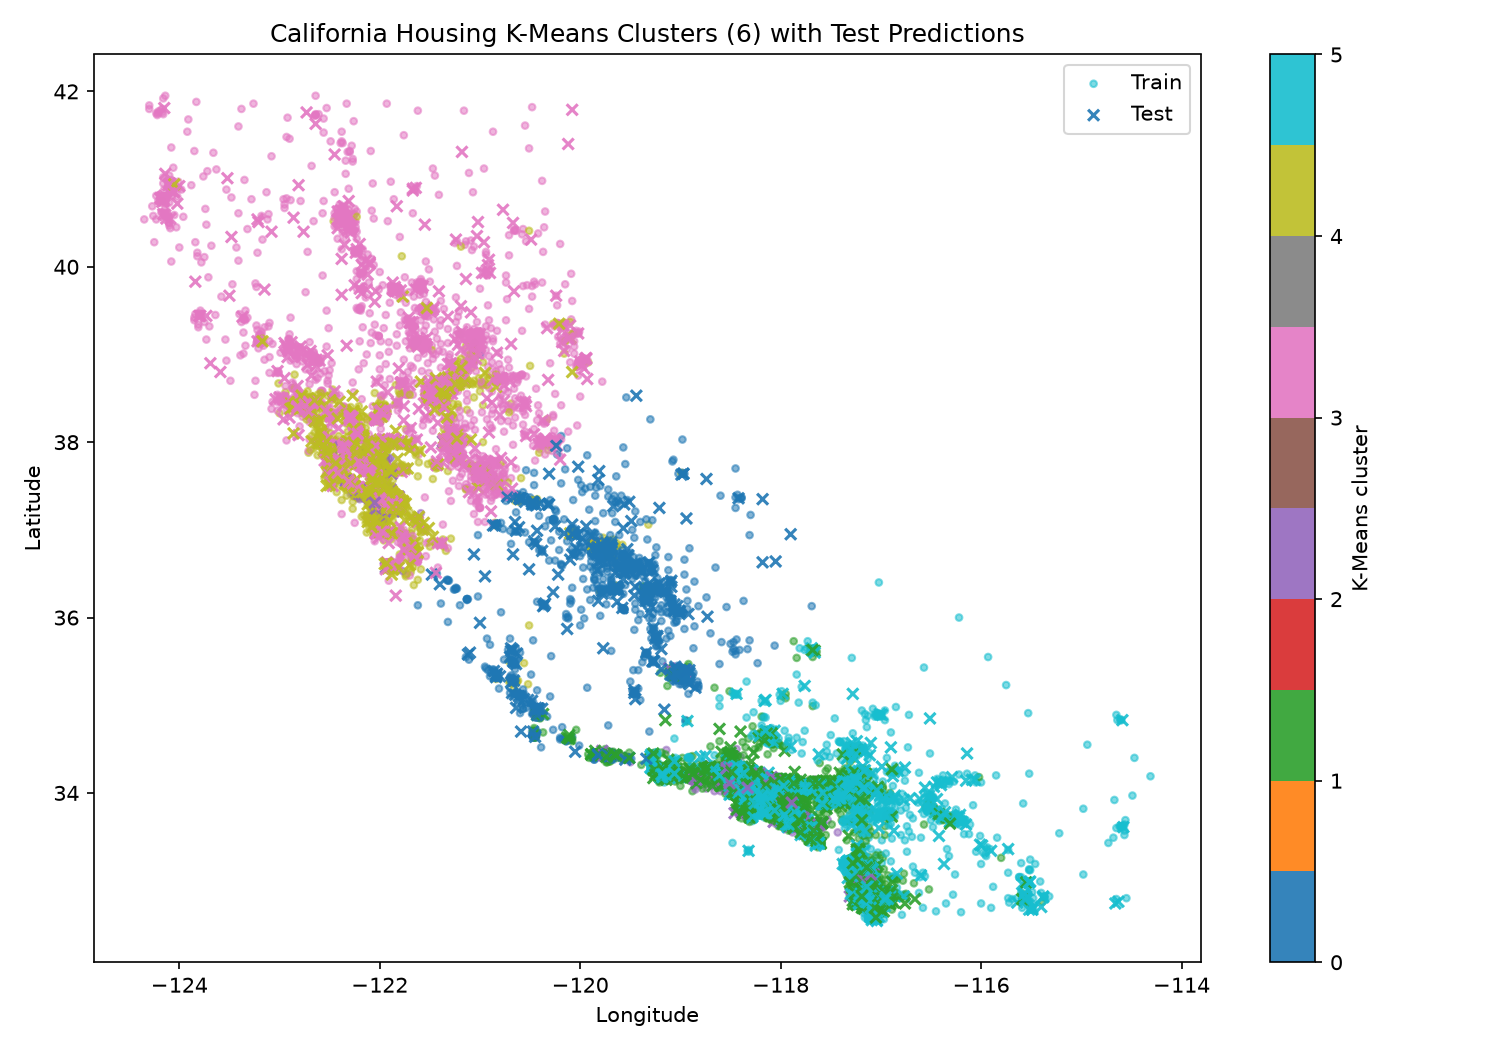

reports/figures/kmeans_clusters.png


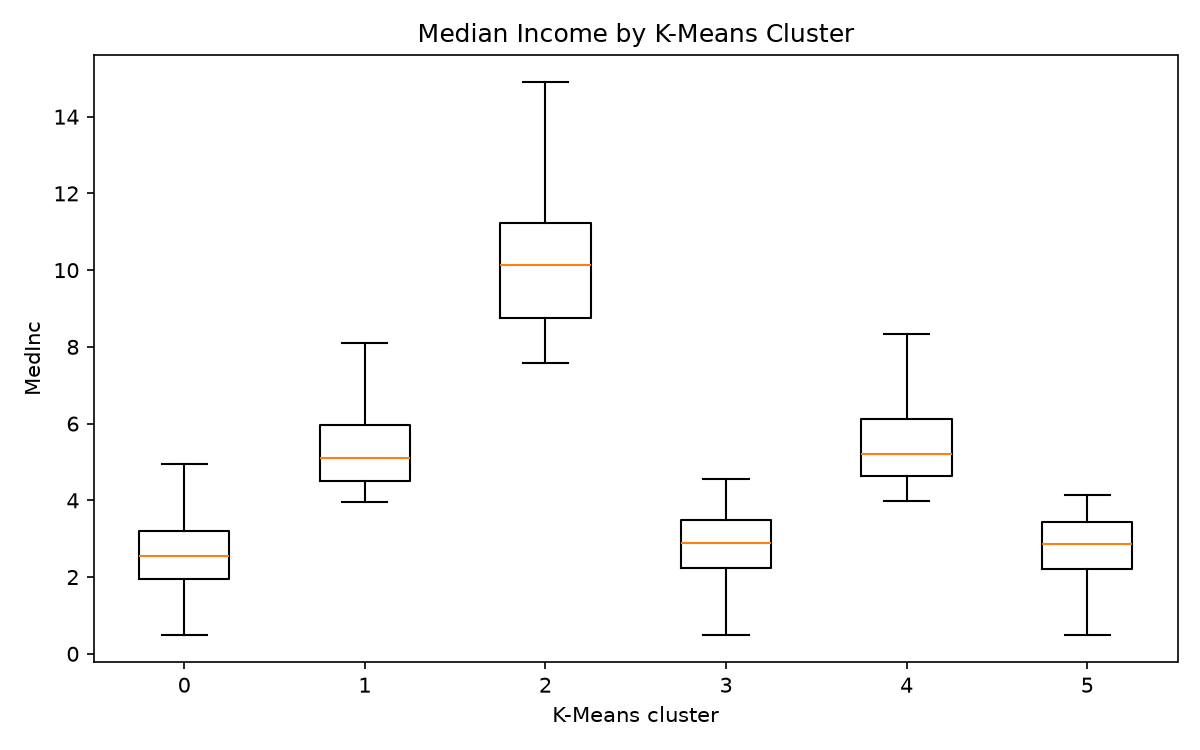

reports/figures/cluster_income_analysis.png


In [4]:
display_repo_figure(app.CLUSTER_PLOT_PATH, "reports/figures/kmeans_clusters.png")
display_repo_figure(app.INCOME_PLOT_PATH, "reports/figures/cluster_income_analysis.png")

### Geographic and income interpretation

The longitude-latitude plot shows spatially coherent groups with overlap at boundaries. The MedInc boxplots show that some clusters sit higher or lower on income, but the boxes overlap. Because K-Means uses standardized location and income together, a cluster is not a pure income tier and is not a census-defined region. It is a distance-based partition in transformed feature space.

## Step 3: Predict clusters for the test set

Test labels come from the already-fitted pipeline `.predict()`. The test points are the crosses on the same geographic plot.

In [5]:
predicted_again = kmeans.predict(X_test)
print("Test labels from fitted pipeline:", sorted(set(test_labels)))
print("All test rows labeled:", len(test_labels) == len(X_test) and test_labels.notna().all())
print("Refit-free agreement:", (predicted_again == test_labels.to_numpy()).all())
print("Test cluster counts:", test_labels.value_counts().sort_index().to_dict())
print(
    "Conclusion: assignment succeeded because every held-out row received a valid "
    "cluster from the training-fitted pipeline. Boundary overlap can still exist."
)

Test labels from fitted pipeline: [0, 1, 2, 3, 4, 5]
All test rows labeled: True
Refit-free agreement: True
Test cluster counts: {0: 337, 1: 829, 2: 112, 3: 962, 4: 514, 5: 1374}
Conclusion: assignment succeeded because every held-out row received a valid cluster from the training-fitted pipeline. Boundary overlap can still exist.


## Step 4: Supervised classification of K-Means labels

A majority-class DummyClassifier is the baseline. Random Forest is the candidate model because the K-Means decision regions are nonlinear combinations of location and income. High scores mean the classifier reproduces K-Means pseudo-labels. They do not prove that the clusters are human-verified geographic classes.

Dummy baseline: {'accuracy': 0.3328488372093023, 'precision_macro': 0.05547480620155038, 'recall_macro': 0.16666666666666666, 'f1_macro': 0.08324245728825881}
Random Forest: {'accuracy': 0.9956395348837209, 'precision_macro': 0.9956571747650235, 'recall_macro': 0.9923396096328165, 'f1_macro': 0.9939763060926651}
              precision    recall  f1-score   support

           0       1.00      0.99      0.99       337
           1       1.00      1.00      1.00       829
           2       1.00      0.98      0.99       112
           3       0.99      0.99      0.99       962
           4       0.99      1.00      0.99       514
           5       1.00      1.00      1.00      1374

    accuracy                           1.00      4128
   macro avg       1.00      0.99      0.99      4128
weighted avg       1.00      1.00      1.00      4128

Model selection: Random Forest is preferred because its macro F1 exceeds the DummyClassifier baseline.
Interpretation: these metrics measure re

Baseline accuracy / macro F1: 0.333 0.083
Random Forest accuracy / macro F1: 0.996 0.994


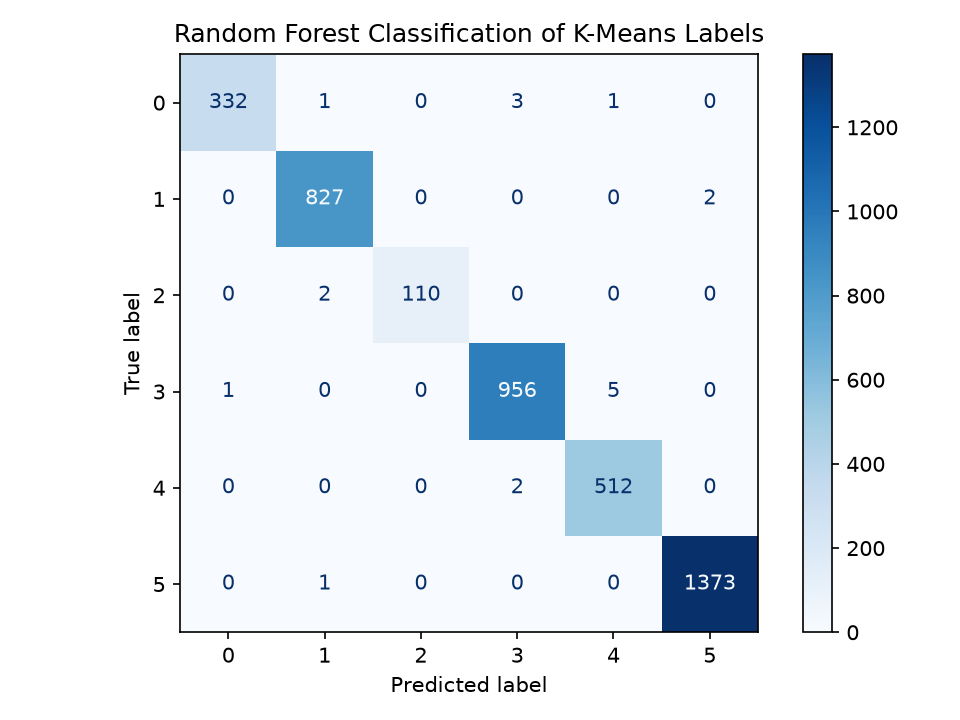

reports/figures/classifier_confusion_matrix.png


In [6]:
baseline, classifier, baseline_metrics, classifier_metrics, pred = (
    app.train_and_evaluate_classifier(X_train, X_test, train_labels, test_labels)
)
print("Baseline accuracy / macro F1:", round(baseline_metrics["accuracy"], 3), round(baseline_metrics["f1_macro"], 3))
print("Random Forest accuracy / macro F1:", round(classifier_metrics["accuracy"], 3), round(classifier_metrics["f1_macro"], 3))
assert classifier_metrics["f1_macro"] > baseline_metrics["f1_macro"]
display_repo_figure(app.CONFUSION_PLOT_PATH, "reports/figures/classifier_confusion_matrix.png")

## Step 5: Save and reload both models

In [7]:
app.persist_and_verify(kmeans, classifier, X_test, test_labels, pred)
print("K-Means artifact: models/kmeans_pipeline.joblib")
print("Classifier artifact: models/cluster_classifier.joblib")

Saved and verified: kmeans_pipeline.joblib, cluster_classifier.joblib
K-Means artifact: models/kmeans_pipeline.joblib
Classifier artifact: models/cluster_classifier.joblib
